# Descriptive Statistics: Describing Data with Numbers

Imagine you measured 344 penguins. Nobody wants to read 344 rows of raw numbers.
Descriptive statistics turn a big pile of data into a few numbers and pictures that tell the story: what is typical, how much values vary, and how things relate to each other.
In this notebook we only **describe** data we already have. We never predict anything. That comes later in the course.

**What you will learn**

- What descriptive statistics are, and how describing differs from predicting
- The types of data: numerical vs categorical
- Central tendency: mean, median, and mode, and when to use which
- Spread: range, variance, standard deviation, quartiles, and IQR
- The shape of a distribution: histograms, skewness, kurtosis, and boxplots
- How to describe categorical data with counts, percentages, and cross tables
- How to compare groups with `groupby` and pivot tables
- How to describe relationships between two numeric columns with scatter plots and correlation
- One-command summaries with `.describe()` and a custom summary function

## How to run this notebook

You can run this notebook in two ways:

- **Locally with Jupyter**: open it in Jupyter Notebook, JupyterLab, or VS Code and run the cells from top to bottom.
- **On Google Colab**: upload the notebook to [colab.research.google.com](https://colab.research.google.com) (or open it straight from GitHub) and run the cells.

The setup cell below installs any missing packages automatically, so it works in both places.
You do not need any account, API key, or local files. The dataset is downloaded from a public URL when you run the load cell.

In [1]:
# SETUP - run this cell first. It installs any missing packages.
# On Google Colab most packages are already installed, so this usually does nothing.
import importlib.util, subprocess, sys

def ensure(package, pip_name=None):
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or package])

ensure("pandas"); ensure("numpy"); ensure("scipy"); ensure("seaborn"); ensure("matplotlib")

## 1. What are descriptive statistics?

**Descriptive statistics** are numbers that summarize data you already collected. Examples: "the average body mass is 4202 grams" or "most penguins live on Biscoe island".

**Describing is not predicting.** This distinction matters a lot:

- *Describing*: "In our data, heavier penguins tend to have longer flippers." (a fact about rows we have)
- *Predicting*: "A new penguin with long flippers will probably be heavy." (a guess about data we do not have)

In this notebook we stay 100% on the describing side.

**Population vs sample, in one paragraph.** The **population** is every individual you care about (all penguins in Antarctica). A **sample** is the part you actually measured (the 344 penguins in our dataset). We almost always work with samples, because measuring everyone is impossible. Descriptive statistics simply summarize the sample in front of us.

**Types of data.** Before computing anything, ask: what kind of values does this column hold?

| Type | Meaning | Penguin example |
|---|---|---|
| Numerical, continuous | Measurements; any value on a scale, decimals allowed | `bill_length_mm` (39.1, 40.3, ...) |
| Numerical, discrete | Counts; whole numbers only | number of penguins observed per island |
| Categorical, nominal | Labels with no natural order | `species` (Adelie, Chinstrap, Gentoo), `island`, `sex` |
| Categorical, ordinal | Labels with a natural order | T-shirt sizes S < M < L (not in this dataset) |

Why it matters: you can take the mean of a numerical column, but the "mean species" makes no sense. Categorical columns get counts and percentages instead.

## 2. Load and meet the data

We will use the **Palmer Penguins** dataset: 344 penguins measured on three islands in Antarctica.
`sns.load_dataset("penguins")` downloads a small public CSV file from GitHub, so it works anywhere with internet.

First step with any dataset: check its **shape** (how many rows and columns).

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

penguins = sns.load_dataset("penguins")

print("Rows and columns:", penguins.shape)

Rows and columns: (344, 7)


344 rows (one per penguin) and 7 columns (one per measurement).

`.head()` shows the first 5 rows, so we can see what the columns look like.

In [3]:
penguins.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


The first rows are all Adelie penguins from Torgersen, because the file is sorted.
To get a more honest peek, `.sample()` picks random rows. We set `random_state=42` so everyone gets the same rows every time (42 is just a convention; any fixed number works).

In [4]:
penguins.sample(5, random_state=42)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
194,Chinstrap,Dream,50.9,19.1,196.0,3550.0,Male
157,Chinstrap,Dream,45.2,17.8,198.0,3950.0,Female
225,Gentoo,Biscoe,46.5,13.5,210.0,4550.0,Female
208,Chinstrap,Dream,45.2,16.6,191.0,3250.0,Female
318,Gentoo,Biscoe,48.4,14.4,203.0,4625.0,Female


`.info()` tells us, for every column: its name, how many non-missing values it has, and its **dtype** (the data type pandas stores it as).

In [5]:
penguins.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


Reading that output:

| Column | dtype in pandas | Kind of data |
|---|---|---|
| `species`, `island`, `sex` | text (`object` or `str`) | categorical (nominal) |
| `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g` | `float64` | numerical (continuous) |

Notice some columns have fewer than 344 non-null values. A **missing value** (shown as `NaN`) means that measurement was not recorded for that penguin. Let us count them per column.

In [6]:
penguins.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

A few measurements are missing, and `sex` is unknown for 11 penguins. That is normal in real data.
Good news: pandas statistics like `.mean()` skip missing values automatically, so we can keep going.

## 3. Central tendency: what is a typical value?

**Central tendency** means: one number that represents the "center" or "typical value" of a column. There are three classics:

- **Mean**: the average. Add all values, divide by how many there are.
- **Median**: the middle value when you sort the data. Half the values are below it, half above.
- **Mode**: the value that appears most often.

**Worked example by hand.** Take these 5 numbers: `2, 3, 3, 5, 12`

- Mean: `(2 + 3 + 3 + 5 + 12) / 5 = 25 / 5 = 5`
- Median: sort them -> `2, 3, 3, 5, 12` -> the middle (3rd) value is `3`
- Mode: `3` appears twice, more than any other value, so the mode is `3`

Note the mean (5) is higher than the median (3). The single large value 12 pulls the mean up, but barely affects the median. Keep that in mind.

Now let pandas do the same work for us.

In [7]:
small = pd.Series([2, 3, 3, 5, 12])

print("Mean:  ", small.mean())
print("Median:", small.median())
print("Mode:  ", small.mode().iloc[0])  # .mode() returns a Series (there can be ties), we take the first

Mean:   5.0
Median: 3.0
Mode:   3


**When should you use which?**

- The **mean** uses every value, which is nice, but it is sensitive to extreme values (**outliers**: values far away from the rest).
- The **median** ignores how extreme the extremes are, so it is robust for **skewed** data (data with a long tail on one side). Think incomes or house prices.
- The **mode** is the only option for categorical data ("the most common species").

**The classic example**: five people are in a room, earning 30k, 35k, 40k, 45k and 50k euros. Then a billionaire walks in. Watch what happens to the mean vs the median.

In [8]:
salaries = pd.Series([30_000, 35_000, 40_000, 45_000, 50_000])
with_billionaire = pd.Series([30_000, 35_000, 40_000, 45_000, 50_000, 1_000_000_000])

print("Before the billionaire:  mean =", f"{salaries.mean():>13,.0f}", "| median =", f"{salaries.median():,.0f}")
print("After the billionaire:   mean =", f"{with_billionaire.mean():>13,.0f}", "| median =", f"{with_billionaire.median():,.0f}")

Before the billionaire:  mean =        40,000 | median = 40,000
After the billionaire:   mean =   166,700,000 | median = 42,500


One person moved the mean from 40,000 to over 166 million, while the median barely changed.
That is why news reports use the *median* income, not the mean.

Now on the real data: the center of penguin body mass, plus the mode of a categorical column.

In [9]:
print("Body mass (grams)")
print("  Mean:  ", round(penguins["body_mass_g"].mean(), 1))
print("  Median:", penguins["body_mass_g"].median())

print()
print("Most common species:", penguins["species"].mode().iloc[0])
print("Most common island: ", penguins["island"].mode().iloc[0])

Body mass (grams)
  Mean:   4201.8
  Median: 4050.0

Most common species: Adelie
Most common island:  Biscoe


The mean (about 4202 g) is a bit higher than the median (4050 g). That small gap hints that the heavy penguins pull the mean up slightly. We will see exactly why in Section 5 when we look at the shape of the data.

## 4. Spread: how much do values vary?

Two datasets can have the same mean and still be completely different. `[49, 50, 51]` and `[0, 50, 100]` both have mean 50, but the second one is far more spread out. **Spread** (also called dispersion) measures how much values differ from each other.

The main tools:

- **Range**: maximum minus minimum. Simple, but it only uses 2 values, so one outlier ruins it.
- **Variance**: the average of the *squared* distances from the mean. Useful in formulas, but its unit is squared (grams squared), which is hard to picture.
- **Standard deviation (std)**: the square root of the variance. Intuition: roughly the *average distance from the mean*, back in normal units (grams). This is the one people quote.

Let us compute all three for body mass.

In [10]:
mass = penguins["body_mass_g"]

print("Min:     ", mass.min(), "g")
print("Max:     ", mass.max(), "g")
print("Range:   ", mass.max() - mass.min(), "g")
print("Variance:", round(mass.var(), 1), "g squared  (hard to interpret)")
print("Std:     ", round(mass.std(), 1), "g          (a typical penguin is ~800 g away from the mean)")

Min:      2700.0 g
Max:      6300.0 g
Range:    3600.0 g
Variance: 643131.1 g squared  (hard to interpret)
Std:      802.0 g          (a typical penguin is ~800 g away from the mean)


**Demystifying the standard deviation.** The formula looks scary, but it is just four small steps. Let us do them one by one with NumPy on five tiny example values:

1. Compute the mean.
2. Compute each value's distance (deviation) from the mean.
3. Square those distances (so negative and positive distances do not cancel out), add them up, and divide by `n - 1`. That is the variance.
4. Take the square root to get back to normal units. That is the standard deviation.

(Why `n - 1` and not `n`? Because we work with a *sample*, dividing by `n - 1` gives a slightly better estimate. pandas does this by default. You do not need to worry about it further.)

In [11]:
values = np.array([3500.0, 3800.0, 4200.0, 3600.0, 3900.0])

step1_mean = values.mean()
step2_deviations = values - step1_mean
step3_variance = (step2_deviations ** 2).sum() / (len(values) - 1)
step4_std = np.sqrt(step3_variance)

print("Step 1 - mean:               ", step1_mean)
print("Step 2 - deviations:         ", step2_deviations)
print("Step 3 - variance:           ", round(step3_variance, 1))
print("Step 4 - standard deviation: ", round(step4_std, 1))

# Check: pandas gives the same answer in one line
print()
print("pandas .std() says:          ", round(pd.Series(values).std(), 1))

Step 1 - mean:                3800.0
Step 2 - deviations:          [-300.    0.  400. -200.  100.]
Step 3 - variance:            75000.0
Step 4 - standard deviation:  273.9

pandas .std() says:           273.9


**Quartiles, percentiles, and the IQR.**

- A **percentile** is the value below which a given percentage of the data falls. The 90th percentile of body mass is the mass that 90% of penguins are below.
- **Quartiles** are the three percentiles that cut the sorted data into four equal parts: Q1 (25th percentile), Q2 (50th, which *is* the median), and Q3 (75th percentile).
- The **IQR** (interquartile range) is `Q3 - Q1`: the width of the middle 50% of the data. Like the median, it is robust to outliers.

In pandas, `.quantile(0.25)` gives Q1 (quantiles use fractions 0 to 1, percentiles use 0 to 100; same idea).

In [12]:
q1 = mass.quantile(0.25)
q2 = mass.quantile(0.50)
q3 = mass.quantile(0.75)

print("Q1 (25th percentile):", q1, "g")
print("Q2 (50th) = median:  ", q2, "g")
print("Q3 (75th percentile):", q3, "g")
print("IQR = Q3 - Q1:       ", q3 - q1, "g  -> the middle half of penguins spans", q3 - q1, "g")

# .describe() gives count, mean, std, min, quartiles and max in one go
mass.describe()

Q1 (25th percentile): 3550.0 g
Q2 (50th) = median:   4050.0 g
Q3 (75th percentile): 4750.0 g
IQR = Q3 - Q1:        1200.0 g  -> the middle half of penguins spans 1200.0 g


count     342.000000
mean     4201.754386
std       801.954536
min      2700.000000
25%      3550.000000
50%      4050.000000
75%      4750.000000
max      6300.000000
Name: body_mass_g, dtype: float64

## 5. The shape of a distribution

A **distribution** is simply how the values of a column are spread over their range: which values are common, which are rare.
The fastest way to *see* a distribution is a **histogram**: it chops the range into bins and counts how many values land in each bin. Tall bar = common values.

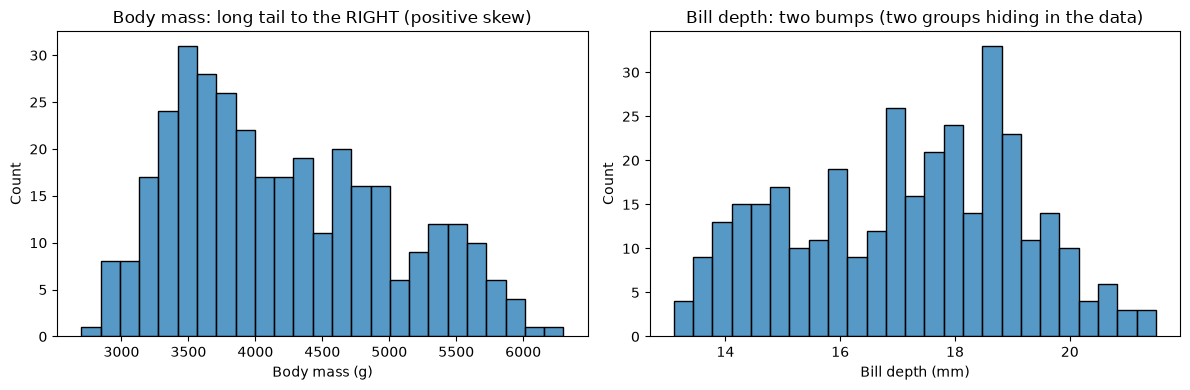

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(penguins["body_mass_g"].dropna(), bins=25, ax=axes[0])
axes[0].set_title("Body mass: long tail to the RIGHT (positive skew)")
axes[0].set_xlabel("Body mass (g)")

sns.histplot(penguins["bill_depth_mm"].dropna(), bins=25, ax=axes[1])
axes[1].set_title("Bill depth: two bumps (two groups hiding in the data)")
axes[1].set_xlabel("Bill depth (mm)")

plt.tight_layout()
plt.show()

Two numbers put the shape into words:

- **Skewness** measures asymmetry.
  - Skewness near 0: roughly symmetric.
  - Positive skewness: long tail to the **right** (a few unusually large values). Mean > median.
  - Negative skewness: long tail to the **left**. Mean < median.
- **Kurtosis** measures how heavy the tails are compared to a bell curve. Positive: more extreme values than a bell curve. Negative: fewer, flatter. (You will use this one rarely; skewness matters more in practice.)

| Skewness value | Plain-language reading |
|---|---|
| about -0.5 to 0.5 | roughly symmetric |
| 0.5 to 1 (or -1 to -0.5) | moderately skewed |
| beyond +1 or -1 | strongly skewed |

`scipy.stats` computes both. We drop missing values first, because scipy does not skip them automatically like pandas does.

In [14]:
mass_clean = penguins["body_mass_g"].dropna()

skewness = stats.skew(mass_clean)
kurt = stats.kurtosis(mass_clean)

print("Body mass skewness:", round(skewness, 2), "-> positive: long tail to the right (some heavy penguins)")
print("Body mass kurtosis:", round(kurt, 2), "-> negative: slightly flatter than a bell curve")

Body mass skewness: 0.47 -> positive: long tail to the right (some heavy penguins)
Body mass kurtosis: -0.73 -> negative: slightly flatter than a bell curve


This confirms what Section 3 hinted: body mass is right-skewed, which is exactly why its mean sits above its median.

**The boxplot: five numbers in one picture.** A **boxplot** draws the quartiles from Section 4:

- The **box** spans Q1 to Q3 (the IQR: the middle 50% of penguins).
- The **line inside the box** is the median.
- The **whiskers** extend to the most extreme values that are still within 1.5 x IQR of the box.
- Any **dots beyond the whiskers** are flagged as potential outliers.

The next cell draws a boxplot of body mass and labels every part.

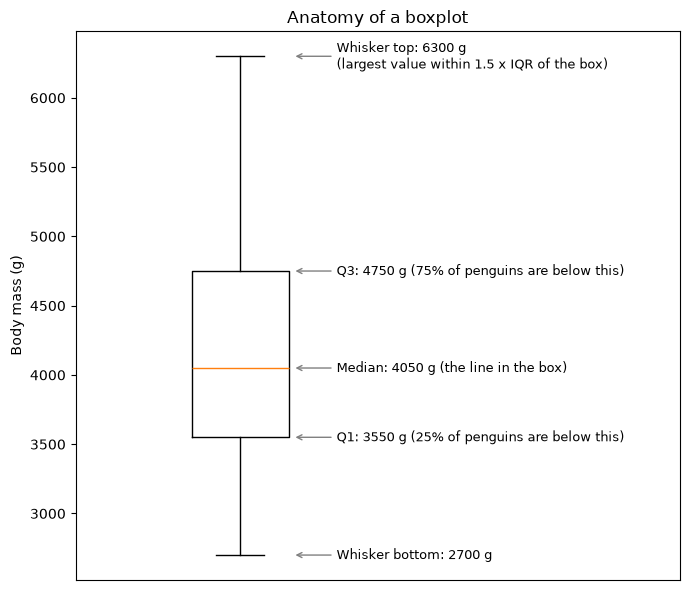

Any dots beyond the whiskers would be potential outliers. Body mass has none.


In [15]:
data = penguins["body_mass_g"].dropna()
q1, med, q3 = data.quantile([0.25, 0.50, 0.75])
iqr = q3 - q1
whisker_low = data[data >= q1 - 1.5 * iqr].min()   # lowest value still inside the fence
whisker_high = data[data <= q3 + 1.5 * iqr].max()  # highest value still inside the fence

fig, ax = plt.subplots(figsize=(7, 6))
ax.boxplot(data, widths=0.35)
ax.set_xlim(0.4, 2.6)
ax.set_xticks([])
ax.set_ylabel("Body mass (g)")
ax.set_title("Anatomy of a boxplot")

labels = [
    (whisker_high, f"Whisker top: {whisker_high:.0f} g\n(largest value within 1.5 x IQR of the box)"),
    (q3, f"Q3: {q3:.0f} g (75% of penguins are below this)"),
    (med, f"Median: {med:.0f} g (the line in the box)"),
    (q1, f"Q1: {q1:.0f} g (25% of penguins are below this)"),
    (whisker_low, f"Whisker bottom: {whisker_low:.0f} g"),
]
for y, text in labels:
    ax.annotate(text, xy=(1.19, y), xytext=(1.35, y),
                va="center", fontsize=9,
                arrowprops=dict(arrowstyle="->", color="gray"))

plt.tight_layout()
plt.show()

print("Any dots beyond the whiskers would be potential outliers. Body mass has none.")

## 6. Describing categorical data

Means and medians make no sense for `species` or `island`. For categorical columns we count.

**`value_counts()`** builds a **frequency table** (a table of how often each category appears). Adding `normalize=True` turns the counts into fractions, which we multiply by 100 to read as percentages.

In [16]:
print("Counts per species:")
print(penguins["species"].value_counts())

print()
print("Percentage per species:")
print((penguins["species"].value_counts(normalize=True) * 100).round(1))

Counts per species:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

Percentage per species:
species
Adelie       44.2
Gentoo       36.0
Chinstrap    19.8
Name: proportion, dtype: float64


**Two categorical columns at once: the cross table.** `pd.crosstab` counts every combination of two categorical columns. Here: how many penguins of each species live on each island?

In [17]:
pd.crosstab(penguins["species"], penguins["island"])

island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


Instantly we see a real pattern in the data: Gentoo penguins only live on Biscoe, Chinstrap only on Dream, and only Adelie live on all three islands.

Adding `margins=True` appends row and column totals.

In [18]:
pd.crosstab(penguins["species"], penguins["island"], margins=True)

island,Biscoe,Dream,Torgersen,All
species,,,,
Adelie,44,56,52,152
Chinstrap,0,68,0,68
Gentoo,124,0,0,124
All,168,124,52,344


**Plotting categorical counts.** The go-to chart is a **horizontal bar chart**: one bar per category, and category names stay easy to read on the left.
(Avoid pie charts as soon as you have more than 3 categories; comparing angles is much harder than comparing bar lengths.)

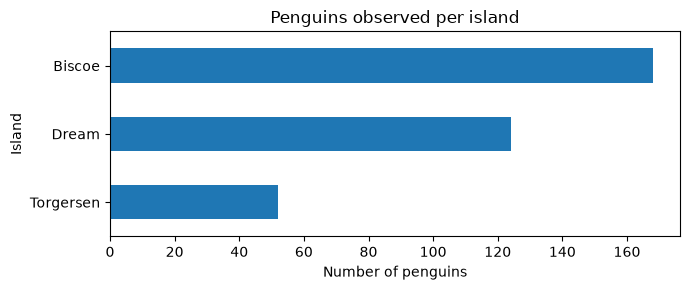

In [19]:
counts = penguins["island"].value_counts()

fig, ax = plt.subplots(figsize=(7, 3))
counts.sort_values().plot.barh(ax=ax)
ax.set_xlabel("Number of penguins")
ax.set_ylabel("Island")
ax.set_title("Penguins observed per island")
plt.tight_layout()
plt.show()

## 7. Comparing groups (still describing!)

Often the interesting question is not "what is the mean overall?" but "what is the mean **per group**?".

**`groupby`** splits the rows into groups (one per category), applies a statistic to each group, and glues the results back together. With **`.agg()`** we can request several statistics at once.

Important: computing statistics per group is still *describing*. We are stating facts about the penguins in our table. We are not testing whether a difference is "real" (that is inferential statistics) and not predicting anything.

In [20]:
penguins.groupby("species")["body_mass_g"].agg(["mean", "median", "std", "count"]).round(1)

,mean,median,std,count
species,,,,
Adelie,3700.7,3700.0,458.6,151
Chinstrap,3733.1,3700.0,384.3,68
Gentoo,5076.0,5000.0,504.1,123


Gentoo penguins are clearly the heavyweights in this dataset: about 1.3 kg heavier than the others, on average.

We can group by **two** columns at once, for example species *and* sex.

In [21]:
penguins.groupby(["species", "sex"])["body_mass_g"].agg(["mean", "count"]).round(1)

mean  count
species   sex                  
Adelie    Female  3368.8     73
          Male    4043.5     73
Chinstrap Female  3527.2     34
          Male    3939.0     34
Gentoo    Female  4679.7     58
          Male    5484.8     61

That output is correct but a bit long. A **pivot table** shows the same numbers as a grid: one grouping variable on the rows, the other on the columns. Much easier to scan.

In [22]:
penguins.pivot_table(values="body_mass_g", index="species", columns="sex", aggfunc="mean").round(1)

sex,Female,Male
species,,
Adelie,3368.8,4043.5
Chinstrap,3527.2,3939.0
Gentoo,4679.7,5484.8


In every species, males are heavier than females on average.

**Seeing group differences: side-by-side boxplots.** One boxplot per group in the same figure shows the centers *and* the spreads at a glance. The `hue` argument splits each box further by a second category.

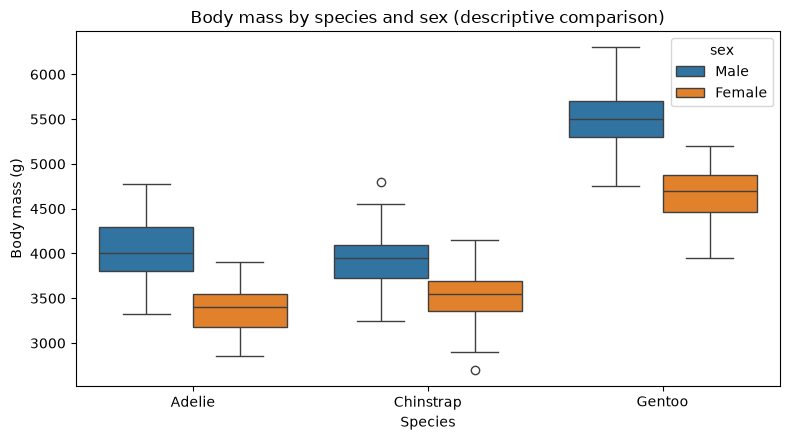

In [23]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.boxplot(data=penguins, x="species", y="body_mass_g", hue="sex", ax=ax)
ax.set_xlabel("Species")
ax.set_ylabel("Body mass (g)")
ax.set_title("Body mass by species and sex (descriptive comparison)")
plt.tight_layout()
plt.show()

## 8. Relationships between two numeric columns

Do penguins with longer flippers also weigh more? To describe how two numeric columns move together, start with a **scatter plot**: one dot per penguin, one column on each axis.

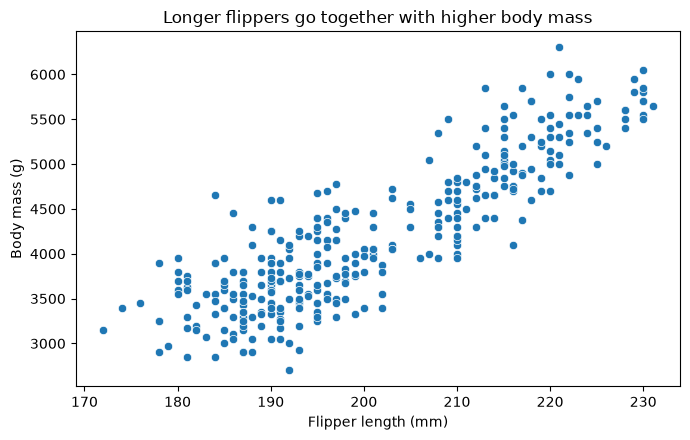

In [24]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.scatterplot(data=penguins, x="flipper_length_mm", y="body_mass_g", ax=ax)
ax.set_xlabel("Flipper length (mm)")
ax.set_ylabel("Body mass (g)")
ax.set_title("Longer flippers go together with higher body mass")
plt.tight_layout()
plt.show()

The dots rise from bottom-left to top-right: in our data, longer flippers and higher mass go together. Now let us put a number on that.

- **Covariance** measures whether two columns move in the same direction (positive) or opposite directions (negative). Problem: its size depends on the units, so "17,000 mm times g" is impossible to interpret. You will rarely quote it; it is mainly a stepping stone to correlation.
- **Pearson correlation** rescales covariance to always fall between **-1 and +1**, unit-free:
  - `+1` = perfect straight-line relationship going up
  - `0` = no straight-line relationship
  - `-1` = perfect straight-line relationship going down
  - Rule of thumb: below 0.3 is weak, 0.3 to 0.7 moderate, above 0.7 strong (same with minus signs).
- **Spearman correlation** is the rank-based alternative: it first replaces values by their rank (1st smallest, 2nd smallest, ...) and then correlates the ranks. Use it when the relationship is curved-but-always-increasing, or when outliers distort Pearson.

In [25]:
flipper = penguins["flipper_length_mm"]
mass = penguins["body_mass_g"]

print("Covariance:          ", round(flipper.cov(mass), 1), "(direction: positive, size: uninterpretable)")
print("Pearson correlation: ", round(flipper.corr(mass), 3))
print("Spearman correlation:", round(flipper.corr(mass, method="spearman"), 3))

Covariance:           9824.4 (direction: positive, size: uninterpretable)
Pearson correlation:  0.871
Spearman correlation: 0.84


A Pearson correlation of about 0.87: a strong positive relationship in our sample.

**All pairs at once: the correlation matrix.** `.corr(numeric_only=True)` computes the correlation between every pair of numeric columns. A seaborn **heatmap** colors the matrix so patterns jump out.

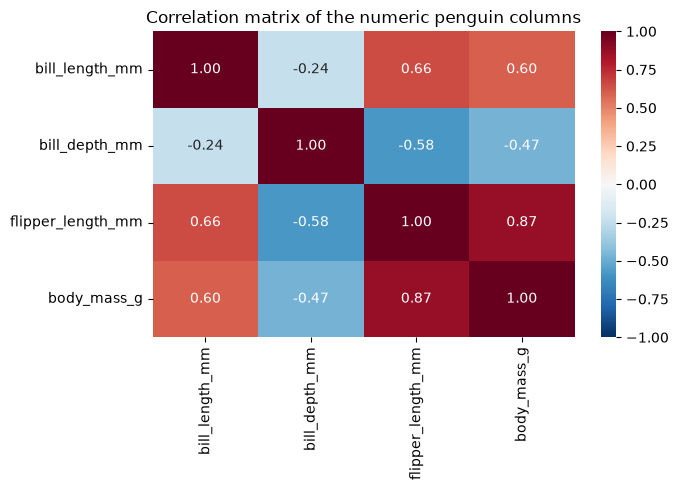

In [26]:
corr_matrix = penguins.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax)
ax.set_title("Correlation matrix of the numeric penguin columns")
plt.tight_layout()
plt.show()

Read it like a distance table: each cell is the correlation between its row and column. The diagonal is always 1 (a column correlates perfectly with itself). Interesting cell: bill depth vs flipper length is *negative* (-0.58), which is a side effect of the species mixing we saw in the bill-depth histogram.

> **Warning: correlation is NOT causation, and describing is NOT predicting.**
>
> - **Not causation.** Ice cream sales and drowning deaths are strongly correlated. Ice cream does not cause drowning: hot weather causes both (a **confounder**: a hidden third variable driving two others). A correlation alone can never tell you *why* two things move together.
> - **Not prediction.** Saying "flipper length and body mass have correlation 0.87 *in these 344 penguins*" is a description of our sample. Using flipper length to estimate the mass of a *new* penguin would be prediction, and that requires the modeling tools of a later module. Describing a relationship is not predicting. We stop here.

## 9. The one-command shortcut

You now know what every number means, so you have earned the shortcut. `.describe()` summarizes all numeric columns at once, and `include="all"` adds the categorical columns too:

- numeric columns get: count, mean, std, min, quartiles, max
- categorical columns get: count, `unique` (number of distinct values), `top` (the mode), `freq` (how often the mode appears)

`NaN` simply means "this statistic does not apply to this column".

In [27]:
penguins.describe(include="all").round(1)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
count,344,344,342.0,342.0,342.0,342.0,333
unique,3,3,NaN,NaN,NaN,NaN,2
top,Adelie,Biscoe,NaN,NaN,NaN,NaN,Male
freq,152,168,NaN,NaN,NaN,NaN,168
mean,NaN,NaN,43.9,17.2,200.9,4201.8,NaN
std,NaN,NaN,5.5,2.0,14.1,802.0,NaN
min,NaN,NaN,32.1,13.1,172.0,2700.0,NaN
25%,NaN,NaN,39.2,15.6,190.0,3550.0,NaN
50%,NaN,NaN,44.4,17.3,197.0,4050.0,NaN
75%,NaN,NaN,48.5,18.7,213.0,4750.0,NaN


**Build your own summary.** `.describe()` is fixed. Sometimes you want your own selection, for example including the median, IQR, and skewness. The function below loops over the numeric columns and returns one tidy row per column: a reusable report you can apply to *any* DataFrame.

We also save the result as a CSV file into an `outputs/` folder next to the notebook, which is a good habit for sharing results.

In [28]:
from pathlib import Path

def numeric_summary(df):
    """One tidy summary row per numeric column of df."""
    rows = []
    for col in df.select_dtypes(include="number").columns:
        s = df[col].dropna()
        rows.append({
            "column": col,
            "count": int(s.count()),
            "mean": s.mean(),
            "median": s.median(),
            "std": s.std(),
            "min": s.min(),
            "q1": s.quantile(0.25),
            "q3": s.quantile(0.75),
            "max": s.max(),
            "iqr": s.quantile(0.75) - s.quantile(0.25),
            "skewness": stats.skew(s),
        })
    return pd.DataFrame(rows).round(2)

summary = numeric_summary(penguins)

# Save the table for later use (the outputs/ folder is created if it does not exist)
Path("outputs").mkdir(exist_ok=True)
summary.to_csv("outputs/penguins_numeric_summary.csv", index=False)
print("Saved to outputs/penguins_numeric_summary.csv")

summary

Saved to outputs/penguins_numeric_summary.csv


,column,count,mean,median,std,min,q1,q3,max,iqr,skewness
0,bill_length_mm,342,43.92,44.45,5.46,32.1,39.22,48.5,59.6,9.27,0.05
1,bill_depth_mm,342,17.15,17.30,1.97,13.1,15.60,18.7,21.5,3.10,-0.14
2,flipper_length_mm,342,200.92,197.00,14.06,172.0,190.00,213.0,231.0,23.00,0.34
3,body_mass_g,342,4201.75,4050.00,801.95,2700.0,3550.00,4750.0,6300.0,1200.00,0.47


## 10. Key takeaways

- Descriptive statistics **summarize the data you have**. Describing is not predicting, and we never crossed that line.
- Know your data types first: **numerical** columns get means and medians, **categorical** columns get counts and percentages.
- **Center**: mean for well-behaved data, **median for skewed data or outliers** (remember the billionaire), mode for categories.
- **Spread**: standard deviation is roughly the average distance from the mean; **IQR** is the robust alternative.
- **Shape**: histograms show it, skewness puts a number on it (long right tail = positive skew), boxplots pack median, quartiles, whiskers, and outliers into one picture.
- `value_counts()` and `pd.crosstab` describe categorical columns; plot counts with **horizontal bar charts**, not pies.
- `groupby(...).agg(...)` and `pivot_table` describe **groups**; side-by-side boxplots show group differences.
- Scatter plots and **correlation** describe how two numeric columns move together. Correlation is **not causation** (ice cream and drownings) and **not prediction**.
- `.describe(include="all")` is the one-command overview, and you can always build a custom summary function.

## 11. Practice exercises

Time to transfer your skills to a new dataset: **tips**, with 244 restaurant bills. Columns: `total_bill` and `tip` (in dollars), `sex` of the bill payer, `smoker`, `day`, `time`, and `size` (number of people at the table).

Run the next cell to load it, then try the exercises **before** looking at the solutions. Everything you need was covered above.

**Exercise 1 - Meet the data.** How many rows and columns does `tips` have? Which columns are numerical and which are categorical? How many missing values are there?

**Exercise 2 - Center and shape.** Compute the mean and median of `total_bill`. Compute its skewness with `stats.skew` and draw a histogram. Is the column skewed? Which measure of center would you report, and why?

**Exercise 3 - Spread.** Compute the standard deviation, the quartiles (Q1 and Q3), and the IQR of the `tip` column.

**Exercise 4 - Categorical description.** Build a frequency table of `day` with counts and percentages, and draw a horizontal bar chart of the counts.

**Exercise 5 - Groups and relationships.** (a) Compute the mean, median, and count of `total_bill` per `day`. (b) Draw a scatter plot of `total_bill` vs `tip` and compute their Pearson correlation. Describe the relationship in one sentence, without predicting anything.

In [29]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 12. Solutions

Try the exercises yourself first. Then compare with the worked answers below.

### Solution 1 - Meet the data

In [30]:
print("Shape:", tips.shape)  # 244 rows, 7 columns
print()
tips.info()

# Numerical: total_bill (continuous), tip (continuous), size (discrete count)
# Categorical: sex, smoker, day, time
print()
print("Missing values per column:")
print(tips.isna().sum())  # tips has no missing values

Shape: (244, 7)

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB

Missing values per column:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64


### Solution 2 - Center and shape

Mean:     19.79
Median:   17.8
Skewness: 1.13


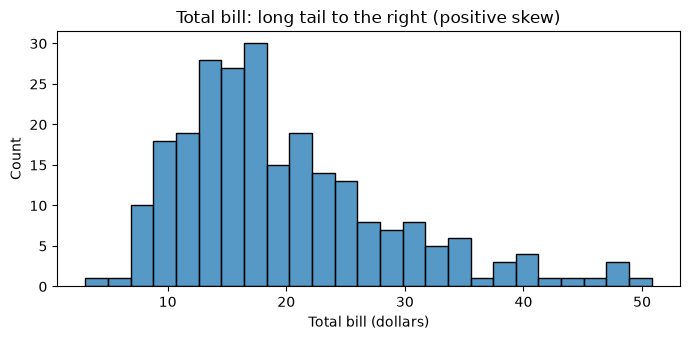

Skewness is about 1.1: strongly right-skewed (a few very expensive bills).
The mean (19.79) is pulled above the median (17.80) by those big bills,
so the MEDIAN is the better 'typical bill' to report.


In [31]:
bill = tips["total_bill"]

print("Mean:    ", round(bill.mean(), 2))
print("Median:  ", round(bill.median(), 2))
print("Skewness:", round(stats.skew(bill.dropna()), 2))

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.histplot(bill, bins=25, ax=ax)
ax.set_xlabel("Total bill (dollars)")
ax.set_title("Total bill: long tail to the right (positive skew)")
plt.tight_layout()
plt.show()

print("Skewness is about 1.1: strongly right-skewed (a few very expensive bills).")
print("The mean (19.79) is pulled above the median (17.80) by those big bills,")
print("so the MEDIAN is the better 'typical bill' to report.")

### Solution 3 - Spread

In [32]:
tip = tips["tip"]

q1 = tip.quantile(0.25)
q3 = tip.quantile(0.75)

print("Std:", round(tip.std(), 2), "dollars")
print("Q1: ", q1, "dollars")
print("Q3: ", q3, "dollars")
print("IQR:", round(q3 - q1, 2), "dollars  -> the middle half of tips spans about 1.56 dollars")

Std: 1.38 dollars
Q1:  2.0 dollars
Q3:  3.5625 dollars
IQR: 1.56 dollars  -> the middle half of tips spans about 1.56 dollars


### Solution 4 - Categorical description

Counts per day:
day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

Percentages per day:
day
Sat     35.7
Sun     31.1
Thur    25.4
Fri      7.8
Name: proportion, dtype: float64


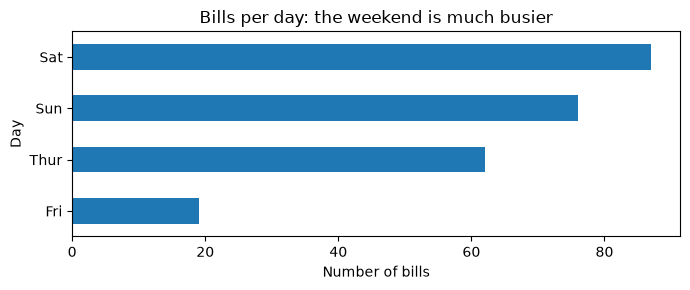

In [33]:
day_counts = tips["day"].value_counts()

print("Counts per day:")
print(day_counts)
print()
print("Percentages per day:")
print((tips["day"].value_counts(normalize=True) * 100).round(1))

fig, ax = plt.subplots(figsize=(7, 3))
day_counts.sort_values().plot.barh(ax=ax)
ax.set_xlabel("Number of bills")
ax.set_ylabel("Day")
ax.set_title("Bills per day: the weekend is much busier")
plt.tight_layout()
plt.show()

### Solution 5 - Groups and relationships

       mean  median  count
day                       
Thur  17.68   16.20     62
Fri   17.15   15.38     19
Sat   20.44   18.24     87
Sun   21.41   19.63     76


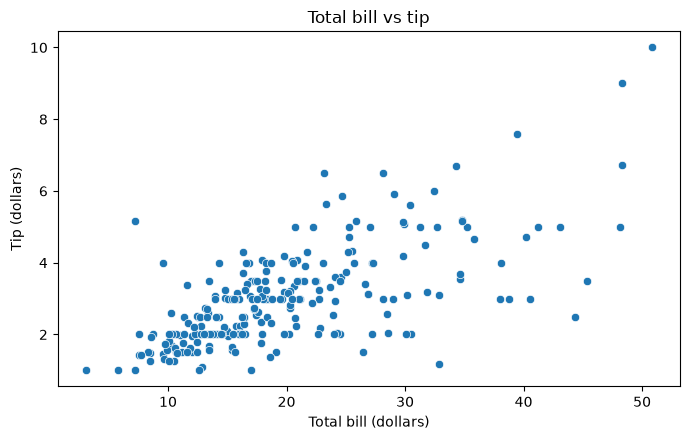

Pearson correlation: 0.676

Description (no prediction!): in this sample, bigger bills tend to come
with bigger tips; the relationship is moderately-to-strongly positive (r = 0.68).


In [34]:
# (a) total_bill described per day
# observed=True just means: only show categories that actually appear in the data
per_day = tips.groupby("day", observed=True)["total_bill"].agg(["mean", "median", "count"]).round(2)
print(per_day)

# (b) scatter plot + Pearson correlation
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.scatterplot(data=tips, x="total_bill", y="tip", ax=ax)
ax.set_xlabel("Total bill (dollars)")
ax.set_ylabel("Tip (dollars)")
ax.set_title("Total bill vs tip")
plt.tight_layout()
plt.show()

r = tips["total_bill"].corr(tips["tip"])
print("Pearson correlation:", round(r, 3))
print()
print("Description (no prediction!): in this sample, bigger bills tend to come")
print("with bigger tips; the relationship is moderately-to-strongly positive (r = 0.68).")